# Анализ поиска в Яндекс Картинках

**Цель**:  проверить гипотезу "интересы людей, пользующихся поиском по картинкам на мобильных устройствах и на компьютерах  отличаются", сравнив запросы на разных платформах. Необходимо сравнить поведение двух сегментов: пользователей поиска по картинкам на desktop и touch.

**Задачи**: 
- Указать даты диапазона
- Рассчитайте кол-во запросов с текстом "ютуб" в каждой платформе
(desktop, touch)
- Вывести топ 10 самых частотных запросов в каждой платформе (desktop,
touch). Указать отличия.
- Чем отличается трафик запросов в течении дня (объяснить)
- Выделить тематики запросов, контрастные для мобильных и компьютеров - темы, доля которых отличаются на разных платформах

## Загрузка библиотек и данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import sqlite3
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans



**Загрузка датасета**

In [2]:
df = pd.read_csv("C:/Users/79533/Desktop/job/data.tsv",header=None,names=["query", "date", "platform"], sep="\t")
df.head(3)

,query,date,platform
0,малевич картины,1631806465,desktop
1,психология,1631781583,touch
2,с днём рождения лена,1631771563,touch


Дата у нас в непривычном формате unix timestamp, переведем в нормальный вид

In [3]:
df["date"] = pd.to_datetime(df["date"], unit="s")
df.head(2)

,query,date,platform
0,малевич картины,2021-09-16 15:34:25,desktop
1,психология,2021-09-16 08:39:43,touch


Смотрим общую информацию

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1114365 entries, 0 to 1114364
Data columns (total 3 columns):
 #   Column    Non-Null Count    Dtype        
---  ------    --------------    -----        
 0   query     1114365 non-null  str          
 1   date      1114365 non-null  datetime64[s]
 2   platform  1114365 non-null  str          
dtypes: datetime64[s](1), str(2)
memory usage: 25.5 MB


У нас более миллиона строк, и три колонки:запрос, дата-время и устройство с которого выполнен запрос(платформа). Пропусков нет, типы данны в порядке (два категориальных признака и один столбец с датой)

## Ответим на первый вопрос: **диапазон дат**

In [5]:
date_min = df["date"].min()
date_max = df["date"].max()

In [6]:
print(f'минимальная дата: {date_min}')
print(f'максимальная дата: {date_max}')

минимальная дата: 2021-08-31 21:00:00
максимальная дата: 2021-09-21 20:59:59


**Данные охватывают период с 31 августа 2021 по 21 сентября 2021 (примерно 3 недели).**

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max
query,1114365,31955,с днём рождения женщине,5404,NaN,NaN,NaN,NaN,NaN,NaN
date,1114365,NaN,NaN,NaN,2021-09-11 15:04:29,2021-08-31 21:00:00,2021-09-06 11:38:58,2021-09-11 16:36:45,2021-09-16 18:38:05,2021-09-21 20:59:59
platform,1114365,2,touch,726101,NaN,NaN,NaN,NaN,NaN,NaN


Не особо ифромативно для наших типов столбцов, но какую-то информацию мы можем увидеть. 

**query** всего уникальных запросов: 31 955, самый частый: "с днём рождения женщине" - 5404 раза. Поиск по картинкам активно используется для поздравлений

**date** данные охватывают период в три недели. Интервалы между квартилями около 5 дней. Можно предположить, что записи по времени распределены примерно равномерно в течение периода.

**platform**. Опечаток нет (только 2 уникальных значения), соотношение платформ: touch 726 101, значит desktop ≈ 388 264 (65%/35%). Людям проще найти картинку с мобильного устройства.

Построим пайчарт, чтобы наглядно оценить процентное соотношение сегментов

In [8]:
platform_counts = df["platform"].value_counts()

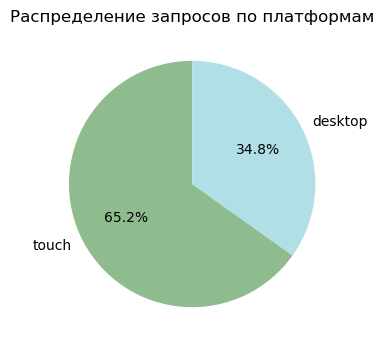

In [9]:
plt.figure(figsize=(4,4))
plt.pie(platform_counts, labels=platform_counts.index, autopct='%1.1f%%',colors=['darkseagreen','powderblue'], startangle=90)
plt.title("Распределение запросов по платформам")
plt.show()

Посмотрим распределение запросов по времени

In [10]:
daily = df.groupby(df['date'].dt.date).size()

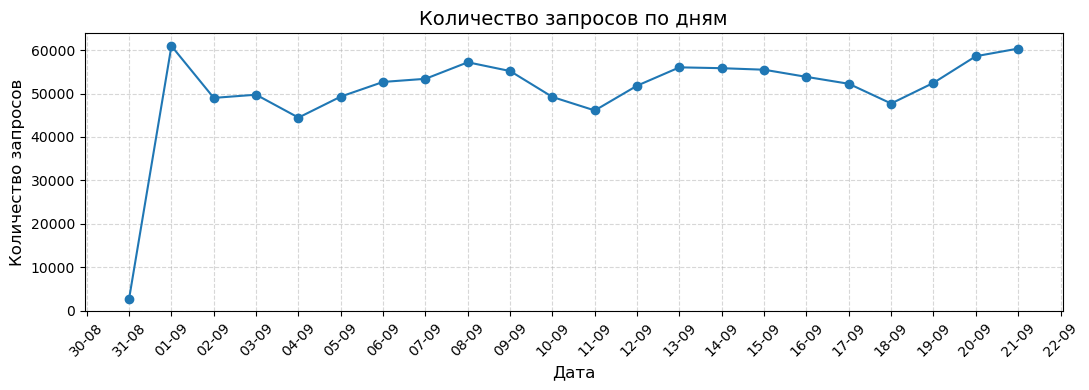

In [11]:
plt.figure(figsize=(11,4))
plt.plot(daily.index, daily.values, marker='o')

plt.title("Количество запросов по дням", fontsize=14)
plt.xlabel("Дата", fontsize=12)
plt.ylabel("Количество запросов", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))  # каждая дата
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))

plt.tight_layout()
plt.show()

In [12]:
daily.head(2)

date
2021-08-31     2773
2021-09-01    60957
dtype: int64

Можно приблизительно посмотреть, что послеживается **недельная динамика**. Суббота-день минимальной активности, начиная с вскр кол-во запросов начинает расти и достигает пика к вт-ср, затем начиная с пт идет на спад. 

Первый день (31 августа) явно выбивается по количеству запросов (2773), т.к. там неплный день, а начиная с вт 21:00 (всего 3 часа). Последний день (21 сентября, вт) тоже неполный до 21:00, но почти (21 час), поэтому снижения кол-ва запросов не наблюдается. 
Если у нас не задача поймать тенденцию, то имеет смысл просуммировать неполные втроники, чтобы получить полный цикл


## Кол-во запросов с текстом "ютуб" в каждой платформе (desktop, touch)

Реализуем запрос через SQL. (у меня проблемы с установкой pandasql, поэтому пойдем через SQLite)

In [13]:
conn = sqlite3.connect(":memory:")
df.to_sql("queries", conn, index=False)

1114365

Создадим простой запрос с группировкой по платформам. Возьмем те запросы, которые содержат в себе сочетание букв 'ютуб', перед этим приведя текст к нижнему регистру.

In [14]:
query = """
SELECT platform, COUNT(*) AS youtube_count
FROM queries
WHERE LOWER(query) LIKE '%ютуб%' OR LOWER(query) LIKE '%youtube%'
GROUP BY platform
"""

метод fetchall() забирает все строки результата запроса в виде списка Python. выведем

In [15]:
result = conn.execute(query).fetchall()
result

[('desktop', 1651), ('touch', 756)]

Действительно, ютуб больше ассоциируется с компьютерами, несмотря на то, что touch трафика больше.
Можно еще проверить как это зависит от дня недели (рабочий/будни). Или день-вечер

Сделаем новый SQL-запрос: **количество "ютуб" по платформе и часам**. (Т.к. у нас не привычный PostgreSQL, а Lite делаем не через EXTRACT, а strftime). Здесь нам не требуется суммировать первый и последний вторники для полного цикла, т.к. мы суммируем по часам без учета дня недели (хотя это было бы полезно)

In [16]:
query_hour = """
SELECT
    platform,
    strftime('%H', date) AS hour,
    COUNT(*) AS youtube_count
FROM queries
WHERE LOWER(query) LIKE '%ютуб%' OR LOWER(query) LIKE '%youtube%'
GROUP BY platform, hour
ORDER BY platform, hour
"""

In [17]:
hour_counts = pd.read_sql_query(query_hour, conn)

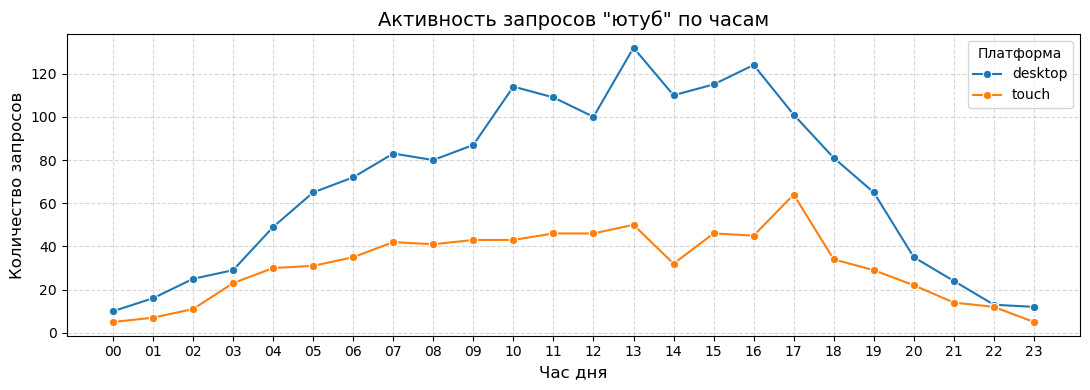

In [18]:
plt.figure(figsize=(11,4))
sns.lineplot(data=hour_counts, x='hour', y='youtube_count', hue='platform', marker='o')
plt.title('Активность запросов "ютуб" по часам', fontsize=14)
plt.xlabel('Час дня', fontsize=12)
plt.ylabel('Количество запросов', fontsize=12)
plt.xticks(range(0,24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Платформа')
plt.tight_layout()
plt.show()

Мы видим, что запросов "ютуб" больше в диапазоне рабочих часов (10 утра-18:00 вечера), при том, что общий трафик больше через touch. В ночные и утренние часы количество запросов закономерно уменьшается. Есть небольшой "провал" 11-12 часов утра у пользователей desktop, это можно объяснить активным рабочим процессом, планерками и т.д.

Надо учитывать, что люди ищут не сам ютуб(видео), а ютуб в каринках. Это может быть поиск превью и скриншотов, мемы и фан-контент, видео-уроки или гайды сопровождающиеся скриншотами, лого и бренды для презентаций.

Desktop чаще используют для работы/учебы, поэтому больше "ютуб"-запросов через ПК, touch — более развлекательные цели

Ради интереса перестроим график, учитывая **только будние дни**

In [19]:
query_hour_weekdays = """
SELECT
    platform,
    strftime('%H', date) AS hour,
    COUNT(*) AS youtube_count
FROM queries
WHERE (LOWER(query) LIKE '%ютуб%' OR LOWER(query) LIKE '%youtube%')
  AND CAST(strftime('%w', date) AS INTEGER) BETWEEN 1 AND 5
GROUP BY platform, hour
ORDER BY platform, hour
"""

In [20]:
hour_counts_weekdays = pd.read_sql_query(query_hour_weekdays, conn)

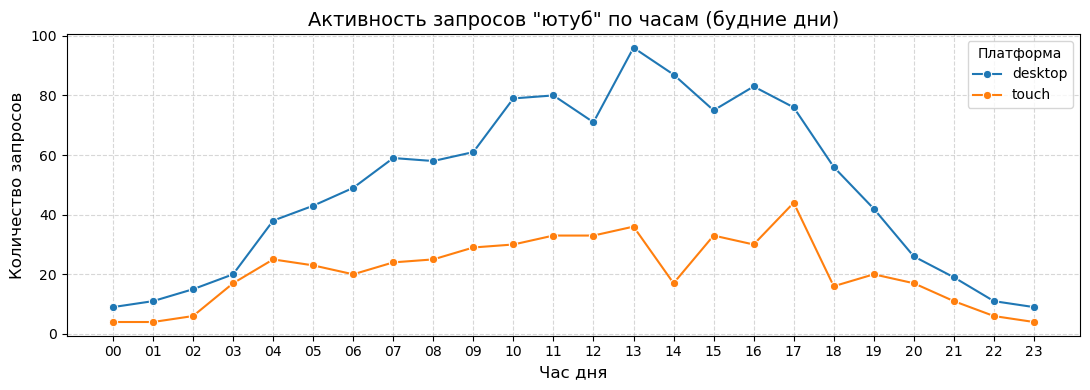

In [21]:
plt.figure(figsize=(11,4))
sns.lineplot(data=hour_counts_weekdays, x='hour', y='youtube_count', hue='platform', marker='o')
plt.title('Активность запросов "ютуб" по часам (будние дни)', fontsize=14)
plt.xlabel('Час дня', fontsize=12)
plt.ylabel('Количество запросов', fontsize=12)
plt.xticks(range(0,24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Платформа')
plt.tight_layout()
plt.show()

Мы видим,что тендеция изменилась не сильно, только пики стали более выраженными и мы видим более резкий спад в конце рабочего дня для пользователей компьютера

Построим lineplot **по дням недели** для запросов "ютуб", где первый и последний вторник суммированы

Создадим дополнительные столбцы с днем недели и часом

In [22]:
df['weekday'] = df['date'].dt.day_name()
df['hour'] = df['date'].dt.hour
df.head(2)

,query,date,platform,weekday,hour
0,малевич картины,2021-09-16 15:34:25,desktop,Thursday,15
1,психология,2021-09-16 08:39:43,touch,Thursday,8


фильтруем то, что содержит ютуб(приведя к нижнему регистру)

In [23]:
youtube_df = df[df['query'].str.lower().str.contains('ютуб|youtube')].copy()

In [24]:
youtube_df

,query,date,platform,weekday,hour
561,youtube,2021-09-10 17:32:43,touch,Friday,17
1301,youtube,2021-09-14 12:16:46,desktop,Tuesday,12
1937,ютуб,2021-09-10 10:16:12,desktop,Friday,10
2293,YouTube,2021-09-10 09:11:34,desktop,Friday,9
2595,ютуб youtube,2021-09-19 07:22:25,touch,Sunday,7
...,...,...,...,...,...
1111959,youtube,2021-09-21 09:10:21,touch,Tuesday,9
1112655,ютуб,2021-09-18 13:22:57,desktop,Saturday,13
1112744,ютуб,2021-09-06 17:58:43,desktop,Monday,17
1112984,YouTube,2021-09-21 13:06:02,desktop,Tuesday,13


In [25]:
weekday_counts = youtube_df.groupby(['weekday', 'platform']).size().reset_index(name='count')

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_counts['weekday'] = pd.Categorical(weekday_counts['weekday'], categories=order, ordered=True)

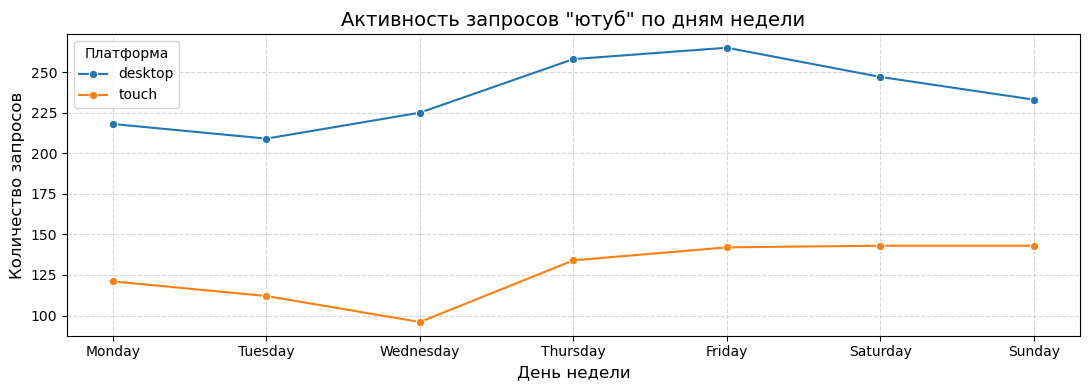

In [26]:
plt.figure(figsize=(11,4))
sns.lineplot(data=weekday_counts, x='weekday', y='count', hue='platform', marker='o')
plt.title('Активность запросов "ютуб" по дням недели', fontsize=14)
plt.xlabel('День недели', fontsize=12)
plt.ylabel('Количество запросов', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Платформа')
plt.tight_layout()
plt.show()

Мы строили похожий график для всех запросов (по неделям), но картина немного отличалась. Мы видим примерно похожие распределения для пользователей ПК и мобильных устройств, однако миниальная активность приходится не на субботу, а на вт-ср, а максимальные значения на пт

## Топ 10 самых частотных запросов в каждой платформе.

для начала почистим с текст запросов. Сделаем функцию для очистки текста

In [27]:
def clean_query(q):
    q = str(q).lower()           
    q = q.replace('ё', 'е')    
    replacements = {
        'youtube': 'ютуб',
        'iphone': 'айфон'
    }
    for old, new in replacements.items():
        q = q.replace(old, new)
    q = re.sub(r'[^\w\s]', '', q)  
    q = q.strip()                 
    return q

In [28]:
df['query'] = df['query'].apply(clean_query)
df['query'].sample(5)

963349     юрий гагарин фото
1005254       расписание пар
251575                   инн
1099191        bocah ngentot
425538         борис краснов
Name: query, dtype: str

In [29]:
top10_desktop = df[df['platform']=='desktop']['query'].value_counts().head(10)
top10_touch = df[df['platform']=='touch']['query'].value_counts().head(10)


print(f"Топ-10 запросов на Desktop: {top10_desktop}")
print(f"\nТоп-10 запросов на Touch: {top10_touch}")

Топ-10 запросов на Desktop: query
календарь 2021                   2810
таблица менделеева               2659
картинки                         1720
ютуб                             1556
английский алфавит               1352
одноклассники социальная сеть    1158
обои на рабочий стол             1143
алфавит                           923
таблица квадратов                 883
таблица умножения                 872
Name: count, dtype: int64

Топ-10 запросов на Touch: query
с днем рождения            7438
с днем рождения женщине    5516
с днем рождения мужчине    4339
погода                     2920
игры                       2877
фильмы                     2775
новости                    2735
музыка                     2729
айфон 13                   2692
спорт                      2666
Name: count, dtype: int64


Так конечно слишком грубо, в touch у нас один топик занял три верхние строки (и уже из этого можно сделать какие-то выводы), но можно попробовать объединить по смыслу. 
первые грубые выводы: 
поиск картинок на Desktop используют в основном в рабочих и образовательных целях. Запросы более деловые (не считая обоев).
В touch скорее daily или фан запросы (быстрая информация "на бегу": какая погода, новости, спорт) или быстро скинуть поздравительную картинку в чат

Попробуем сделать кластеризацию запросов (отдельно для обоих сегментов). Используем мешок слов

In [30]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=5,max_df=0.7,stop_words=None)
X = vectorizer.fit_transform(df['query'])
print("Размер матрицы:", X.shape)

Размер матрицы: (1114365, 32049)


In [31]:
n_clusters = 30
kmeans = KMeans(n_clusters=n_clusters,random_state=42,n_init=10)
df['cluster'] = kmeans.fit_predict(X)
print("Кластеры созданы")

C:\Users\79533\.conda\envs\lisa\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Кластеры созданы


In [32]:
cluster_sizes = df['cluster'].value_counts()
print(cluster_sizes.head(10))

cluster
12    867933
3      39998
2      23695
17     17451
0      17424
28     16656
22     13611
18     11186
8      11057
7      10923
Name: count, dtype: int64


In [33]:
for cluster_id in cluster_sizes.head(10).index:
    print(f"\nКластер {cluster_id}")
    print(df[df['cluster'] == cluster_id]['query'].value_counts().head(5))


Кластер 12
query
таблица менделеева    4937
игры                  3579
фильмы                3246
новости               3194
спорт                 3175
Name: count, dtype: int64

Кластер 3
query
с днем рождения                 8189
с днем рождения мужчине         4744
с днем рождения девушке         1580
поздравления с днем рождения    1405
открытки с днем рождения        1163
Name: count, dtype: int64

Кластер 2
query
картинки                           3521
доброе утро                        2487
доброе утро картинки               1785
1 сентября картинки                 876
доброе утро картинки позитивные     790
Name: count, dtype: int64

Кластер 17
query
фото                      1296
поиск по фото              784
опята фото                 226
фото на аву                221
жанполь бельмондо фото     188
Name: count, dtype: int64

Кластер 0
query
карта метро москвы    2084
карта метро           1998
карта мира            1838
схема метро москвы    1777
карта россии          1238

Мы видим, что условно по смыслу кластер разбил, но 1) у нас есть пересечения 2) плохо что разлекательное он путает с образовательным (таблица менделеева и погода). 
первую ошибку устранить довольно легко, используем пост-обработку по топовым словам

In [34]:
terms = vectorizer.get_feature_names_out()
top_words_per_cluster = {}

for i in range(n_clusters):
    center = kmeans.cluster_centers_[i]
    top_indices = np.argsort(center)[-10:][::-1]
    top_words = [terms[ind] for ind in top_indices]
    top_words_per_cluster[i] = set(top_words)

Сравниваем кластеры по Jaccard similarity (пересечение, объединение топ-слов):

In [35]:
def jaccard(a, b):
    return len(a & b) / len(a | b)

In [36]:
merged_clusters = {}
for i in range(n_clusters):
    for j in range(i+1, n_clusters):
        if jaccard(top_words_per_cluster[i], top_words_per_cluster[j]) > 0.4:
            merged_clusters[j] = i 

In [37]:
df['merged_cluster'] = df['cluster'].apply(lambda x: merged_clusters.get(x, x))

In [38]:
merged_sizes = df['merged_cluster'].value_counts()

In [39]:
for cluster_id in merged_sizes.index:
    print(f"\n=== Кластер {cluster_id} ===")
    print(df[df['merged_cluster'] == cluster_id]['query'].value_counts())


=== Кластер 12 ===
query
таблица менделеева       4937
игры                     3579
фильмы                   3246
новости                  3194
спорт                    3175
                         ... 
нежное кулинария            1
винкс фильмы                1
мода негры                  1
психология с негром         1
технологии с собаками       1
Name: count, Length: 24985, dtype: int64

=== Кластер 3 ===
query
с днем рождения                                                              8189
с днем рождения женщине                                                      6102
с днем рождения мужчине                                                      4744
поздравления с днем рождения женщине                                         1585
с днем рождения девушке                                                      1580
                                                                             ... 
с днем рождения женщине открытки анимированные                                  8
ален

более менее приемлемые смысловые группы. Но в нашем случае кластеризация не состоятельна, потому что нам нужно вывести топ запросов, а например в кластере 5 получилась смесь всего с довольно большим количеством запросов и отдельные элементы могут встречаться чаще чем например весь кластер 3.

Можно было пойти путем образования смысловых групп через ruBert, но мы пойдем ужасным ручным пцтем и просто соберем словарь из наиболее частых тем кластеров (сейчас это сделать реально).

In [40]:
tags = ['днем рождения', 'сентября',
        'кино', 'раскраск', 'метро', 'утро','обои',
        'алфавит', 'зодиак', 'погода', 'айфон','маникюр', 'календарь','богород','литература',
        'разбор', 'спорт', 'технологии', 'девушк', 'психолог', 'здоровье', 'кулинария',
        'история', 'мода','наука', 'новости', 'музыка', 'кс го','аватарк']

Мы можем присвоить тег, если в запросе встречается слово. Из минусов запросы в которых встречаются оба слова, например "спортивные девушки" обрабатывать сложнее. Сейчас мы пойдем по самому простому пути и присвоим первую метку, но если что сможно усложнить.

In [41]:
def replace_tags_in_query(query, tags):
    for tag in tags:
        if tag in query:
            return tag         
    return query 

In [42]:
df['query_clean'] = df['query'].apply(lambda x: replace_tags_in_query(x, tags))

In [43]:
df

,query,date,platform,weekday,hour,cluster,merged_cluster,query_clean
0,малевич картины,2021-09-16 15:34:25,desktop,Thursday,15,20,20,малевич картины
1,психология,2021-09-16 08:39:43,touch,Thursday,8,12,12,психолог
2,с днем рождения лена,2021-09-16 05:52:43,touch,Thursday,5,3,3,днем рождения
3,зверополис фильмы,2021-09-16 10:19:59,touch,Thursday,10,12,12,зверополис фильмы
4,алабай собака фото,2021-09-16 10:04:05,touch,Thursday,10,17,17,алабай собака фото
...,...,...,...,...,...,...,...,...
1114360,бабочка,2021-09-12 19:40:53,touch,Sunday,19,12,12,бабочка
1114361,все республики россии,2021-09-12 16:08:54,touch,Sunday,16,12,12,все республики россии
1114362,кухня в стиле лофт,2021-09-12 07:37:32,touch,Sunday,7,12,12,кухня в стиле лофт
1114363,топор,2021-09-12 12:22:27,desktop,Sunday,12,12,12,топор


**Топ-10 запросов для desktop**

In [44]:
desktop_df = df.query('platform=="desktop"')
desktop_top = desktop_df['query_clean'].value_counts().head(10)
desktop_top

query_clean
календарь             9734
раскраск              8899
обои                  5798
алфавит               5794
днем рождения         5584
метро                 2892
сентября              2829
таблица менделеева    2659
спорт                 1987
разбор                1982
Name: count, dtype: int64

**Топ-10 запросов для touch**

In [45]:
touch_df = df.query('platform=="touch"')
touch_top = touch_df['query_clean'].value_counts().head(10)
touch_top

query_clean
днем рождения    55357
утро             17936
сентября         15901
метро            10961
айфон             7171
маникюр           7050
алфавит           6791
спорт             6493
обои              6354
календарь         6330
Name: count, dtype: int64

Мы видим, что гипотеза подтверждается: основные запросы с ПК и мобильных устройств немного различаются. 
На пк в топе есть более серьезные/учебные темы: таблица Менделеева, разбор, также раскраски (потому что их удобно распечатать с компа), лидирует календарь(планирование событий).

На мобильных устройствах первое место популярности занимает тема дня рождения (открытки удобно отправлять в мессенджерах с телефона), также появляются такие теги как маникюр, айфон, утро. Можно отметить, что это больше похоже на  темы "на бегу": найти референс, чтобы показать мастеру маникюра, отправить пожелание хорошего утра дорогому человеку. Почитать в дороге сравнение нового айфона. 

Есть темы которые пересекаются: спорт, обои, календарь, алфавит, метро, сентября. 

## Различия в трафике запросов в течении дня

Посмотрим общий трафик по часам для обоих сегментов

In [46]:
hour_counts = (df.groupby(['platform', 'hour']).size().reset_index(name='request_count'))

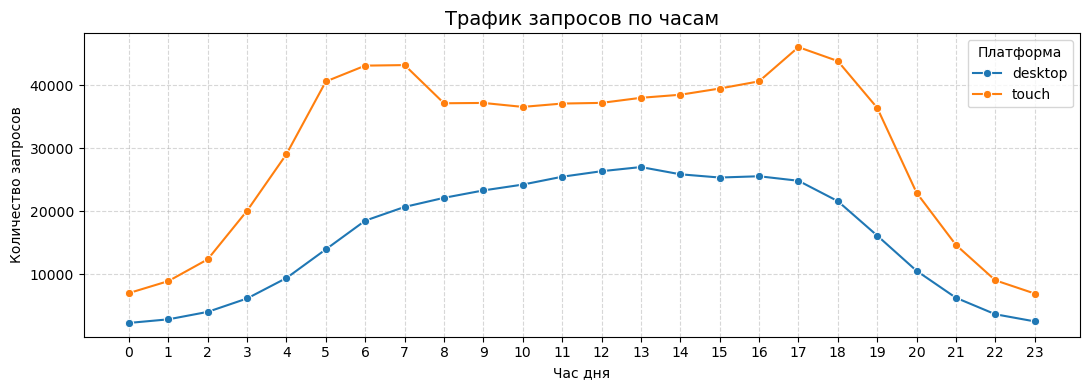

In [47]:
plt.figure(figsize=(11,4))
sns.lineplot(data=hour_counts,x='hour',y='request_count',hue='platform',marker='o')

plt.title('Трафик запросов по часам', fontsize=14)
plt.xlabel('Час дня')
plt.ylabel('Количество запросов')
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Платформа')
plt.tight_layout()
plt.show()

Мы видим, что трафик touch в целом превышает трафик Desktop. 

У **мобильных устройств** есть выраженные пики: раннее утро (первым делом берем в руки телефон с будильником (5-7 утра). С учетом того, что у нас трафик только картинок в яндексе, то скорее всего это как раз утренняя волна "пожеланий доброго утра" и поздравлений в днем рождения (топ-10 запросов для мобильных устройств). Вечерний пик (5-6) - возможно обусловлен тем, что в это время люди добираются с работы.

**Для ПК** распределение выглядит немного иначе: мы видим плавный пик в рабочие часы (подъем начиная с 6 утра, пик в час дня, далее почти стабильно до 5 вечера и спад).Более "утилитарные" запросы (погода, таблица менделеева, метро, новости.).Часто рост запросов типа YouTube, но в рабочем контексте

*Поведенческое объяснение*

Трафик отражает режим дня человека:
днём - рациональное поведение (у desktop пик), вечером - развлекательное (втрой пик для мобильных устройств). Утром - информационное (схватить телефон почитать новости, рассылка в мессенджере). Ночью - случайное / персональное (+зависит от графика дня человека).

**Построим графики распределения топ-10 запросов по часам для каждого сегмента по отдельности.**

In [48]:
top_queries = desktop_top.index.tolist()
desktop_top_df = desktop_df[desktop_df['query_clean'].isin(top_queries)]

In [49]:
hour_query = (desktop_top_df.groupby(['hour', 'query_clean']).size().reset_index(name='count'))

In [50]:
pivot_df = (hour_query.pivot(index='hour', columns='query_clean', values='count').
    fillna(0).reindex(range(24), fill_value=0))

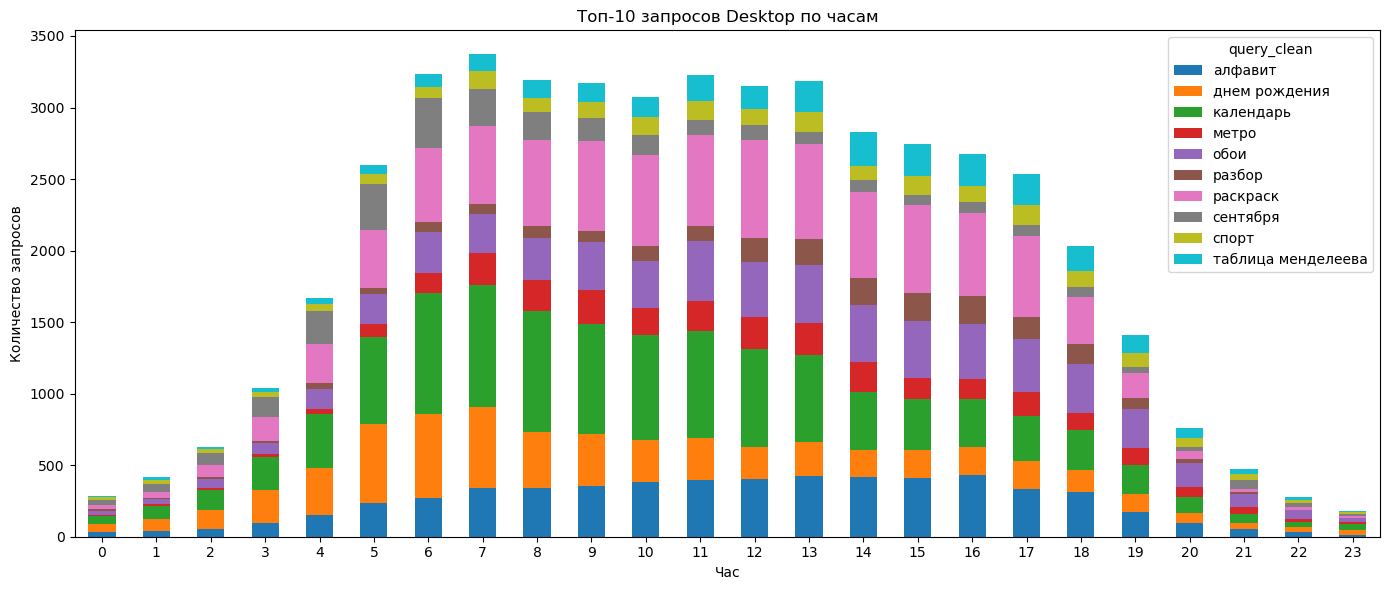

In [51]:
pivot_df.plot(kind='bar',stacked=True,figsize=(14,6))

plt.title('Топ-10 запросов Desktop по часам')
plt.xlabel('Час')
plt.ylabel('Количество запросов')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

для Desktop пропорции сохраняются примерно одинаковыми в течение дня (нет явных тенценций). 

Можно отметить, что:
- запросы "сентября" чаще в утреннее время
- раскраски ищут во время бодрствования детей (или чуть раньше как подготовка ко дню), а после 8 вечера,когда дети спят количество запросов снижается
- разборы(слова,предложений и т.д) активнее  ищут в учебное/рабочее время. с 11:00-19:00
- календарь чаще ищут с 4 утра до 13:00
- поздравления с днем рождения активнее ищут ранним утром (5:00-7:00)

In [52]:
top_queries_touch = touch_df['query_clean'].value_counts().head(10).index.tolist()
touch_top_df = touch_df[touch_df['query_clean'].isin(top_queries_touch)]

In [53]:
hour_query_touch = (touch_top_df.groupby(['hour', 'query_clean']).size().reset_index(name='count'))

In [54]:
pivot_df_touch = (hour_query_touch.pivot(index='hour', columns='query_clean', values='count')
    .fillna(0).reindex(range(24), fill_value=0))

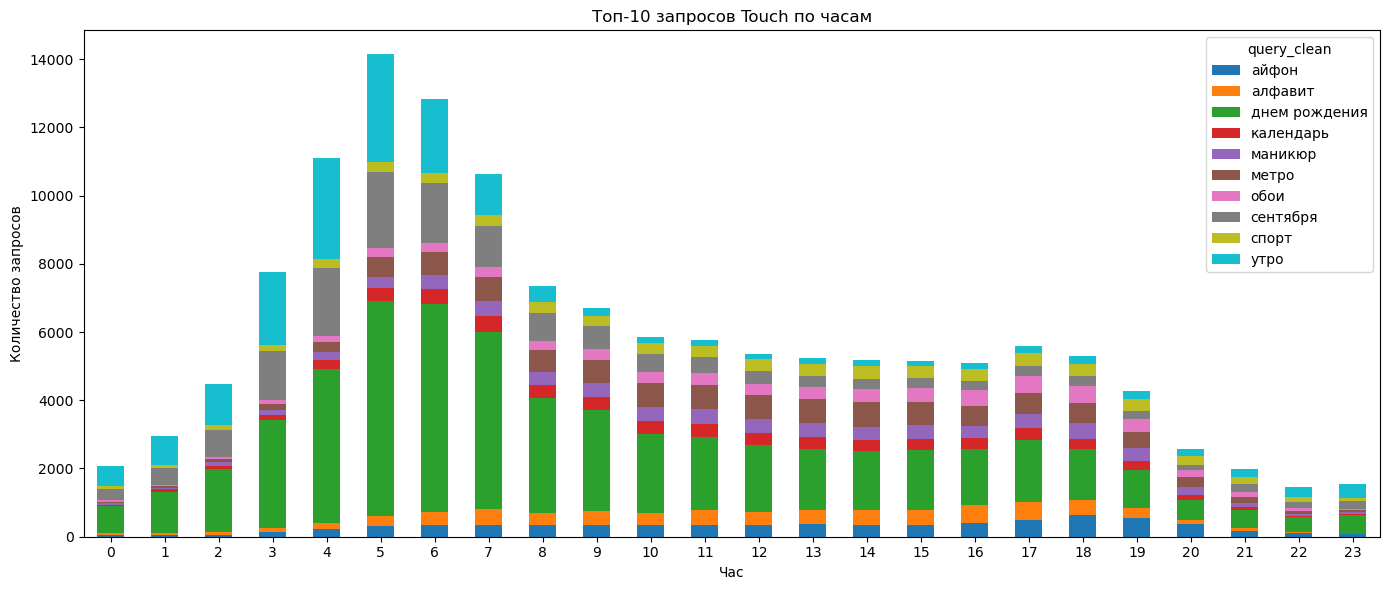

In [55]:
pivot_df_touch.plot(kind='bar',stacked=True,figsize=(14,6))

plt.title('Топ-10 запросов Touch по часам')
plt.xlabel('Час')
plt.ylabel('Количество запросов')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Для touch можно выделить некоторые тенденции:

- картинки с тегом "утро" наиболее популярны 0:00-7:00
- картинки с днем рождения (около 50% топ-10 запросов) с 0:00 до 8:00
- с 6 утра до 19:00 люди чаще ищут карты метро
- спорт популярнее с 8 утра до 21:00
- обои чуть чаще хотят поменять с 14 до 19:00
- айфоном больше интересуются в вечкерние часы (16:00-20:00)



## Выделить тематики запросов, контрастные для мобильных и компьютеров - темы, доля которых отличаются на разных платформах

Смотрим не на абсолютные значения, а на долю темы внутри платформы.

Посчитаем частоты в каждом сегменте:

In [56]:
desktop_counts = desktop_df['query_clean'].value_counts()
touch_counts = touch_df['query_clean'].value_counts()

Переводим в доли

In [57]:
desktop_proportion = desktop_counts / len(desktop_df)
touch_proportion = touch_counts / len(touch_df)

In [58]:
desktop_proportion

query_clean
календарь                           0.025071
раскраск                            0.022920
обои                                0.014933
алфавит                             0.014923
днем рождения                       0.014382
                                      ...   
путешествия девочки                 0.000003
андертейл образование               0.000003
какие птицы улетают на юг осенью    0.000003
путешествия рисунки                 0.000003
королевский опенок                  0.000003
Name: count, Length: 18619, dtype: float64

Объединим

In [59]:
contrast_df = pd.DataFrame({'desktop_proportion': desktop_proportion,'touch_proportion': touch_proportion}).fillna(0)

contrast_df['difference'] = contrast_df['touch_proportion'] - contrast_df['desktop_proportion']

In [60]:
mobile_dominant = contrast_df.sort_values('difference', ascending=False).head(15)
mobile_dominant

,desktop_proportion,touch_proportion,difference
query_clean,,,
днем рождения,0.014382,0.076239,0.061857
утро,0.002898,0.024702,0.021804
сентября,0.007286,0.021899,0.014613
метро,0.007449,0.015096,0.007647
маникюр,0.002609,0.009709,0.007100
богород,0.001095,0.006523,0.005428
погода,0.002573,0.007770,0.005197
айфон,0.004798,0.009876,0.005078
новости,0.002060,0.006653,0.004593


In [61]:
mobile_dominant.index

Index(['днем рождения', 'утро', 'сентября', 'метро', 'маникюр', 'богород',
       'погода', 'айфон', 'новости', 'мода', 'кулинария', 'наука',
       'технологии', 'психолог', 'история'],
      dtype='str', name='query_clean')

Список тем, более популярных в мобильном сегменте это повседневные и ситуативные запросы (погода, метро, утро). Пользователь ищет инфомацию "в моменте" в дороге или вне дома. Популярны эмоционально-социальные темы (день рождения,поздравления и мемы 1 и 3 сентября,праздник богородицы) - чаще это просто быстро найти и отправить. Также популярен lifestyle-контент (маникюр, мода, кулинария, психолог, технологии, айфон)

Мобильные платформы (touch) — это скорее сценарий "личного пользования": досуг, поздравления, бытовые потребности, быстрые проверки информации.

In [62]:
desktop_dominant = contrast_df.sort_values('difference').head(15)
desktop_dominant

,desktop_proportion,touch_proportion,difference
query_clean,,,
раскраск,0.022920,0.000972,-0.021948
календарь,0.025071,0.008718,-0.016353
обои,0.014933,0.008751,-0.006182
алфавит,0.014923,0.009353,-0.005570
таблица менделеева,0.006848,0.003137,-0.003711
ютуб,0.004008,0.001049,-0.002958
одноклассники социальная сеть,0.002983,0.000028,-0.002955
картинки,0.004430,0.002480,-0.001950
таблица квадратов,0.002274,0.000808,-0.001466


In [63]:
desktop_dominant.index

Index(['раскраск', 'календарь', 'обои', 'алфавит', 'таблица менделеева',
       'ютуб', 'одноклассники социальная сеть', 'картинки',
       'таблица квадратов', 'таблица умножения', 'спасибо за внимание',
       'картинки на рабочий стол', 'minecraft',
       'расписание уроков шаблоны распечатать', 'фон для презентации'],
      dtype='str', name='query_clean')

контрастные темы Desktop-сегмента связаны с учебной активностью (таблица умножения, таблица менделеева, алфавит, расписание уроков), печатными материалами и презентациями (раскраски, шаблоны, фон для презентации, спасибо за внимание), какими-то рабочими сценариями и планированием (календарь), настройкой рабочего пространства (обои, картинки на рабочий стол) и развлечения, которые чаще запускают с компа (minecraft,ютуб). Также возможно за компом чуть более возрастная аудитория, которая меньше пользуется смартфонами на ходу (но это не утверждение, а предположение. Такое впечатление создается от соцсети одноклассники, т.к. датасет у нас 21 года. Хотя на данный момент она снова набирает популярность с появлением макса и замедлением телеграмма)

Desktop — это скорее "рабочий/учебный" сценарий: печать, подготовка материалов, презентации, школьные задания.

## Выводы

### Диапазон дат
**Данные охватывают период с 31 августа 2021 по 21 сентября 2021 (примерно 3 недели).**

Мы видим, что заппросы очень коррелируют с событиями (датой): запросы про день знаний, 1 сентября, 3 сентября, айфон 13 (iPhone 13 был официально представлен Apple 14 сентября 2021 года,старт продаж состоялся 24 сентября 2021 года). 

Это подтверждает чувствительность поиска к актуальной повестке и календарным событиям.
### Анализ количества запросов "ютуб" по платформам (desktop vs touch)
 
   - Desktop: 1651 запроса, touch: 756 запросов 
   - Несмотря на больший общий трафик через touch, **относительно запросов "ютуб" чаще встречаются на desktop**.  
   - Desktop-пользователи делают пик запросов в рабочие часы (10:00–18:00), с небольшим провалом около 11–12 утра, что объясняется занятостью на работе/учёбе и планёрками.  
   - Люди ищут не сами видео, а **превью, скриншоты, мемы, обучающие гайды, логотипы и брендовые изображения**.
     
Предположение:
   - судя по графику активности по часам Desktop чаще используется для работы и учебы — больше профессиональных и учебных запросов.  
   - Touch больше для развлекательных целей — мемы, фан-контент и лёгкий поиск.
     
Разница подчёркивает **различие поведения пользователей по платформам**.

### Топ 10 самых частотных запросов в каждой платформе.
**поправить**
Мы видим, что гипотеза подтверждается: основные запросы с ПК и мобильных устройств немного различаются. 
На пк в топе есть более серьезные/учебные темы: таблица Менделеева, разбор, также раскраски (потому что их удобно распечатать с компа), лидирует календарь.

На мобильных устройствах первое место популярности занимает тема дня рождения (открытки удобно отправлять в мессенджерах с телефона), также появляются такие теги как маникюр, айфон, утро. Можно отметить, что это больше похоже на  темы "на бегу": найти референс, чтобы показать мастеру маникюра, отправить пожелание хорошего утра дорогому человеку. Почитать в дороге сравнение нового айфона. 

Есть темы которые пересекаются: спорт, обои, календарь, алфавит, метро, сентября. 

## Различия в трафике запросов в течении дня

Мы видим, что трафик touch в целом превышает трафик Desktop.

У мобильных устройств есть выраженные пики: раннее утро (первым делом берем в руки телефон с будильником (5-7 утра). С учетом того, что у нас трафик только картинок в яндексе, то скорее всего это как раз утренняя волна "пожеланий доброго утра" и поздравлений в днем рождения (топ-10 запросов для мобильных устройств). Вечерний пик (5-6) - возможно обусловлен тем, что в это время люди добираются с работы.

Для ПК распределение выглядит немного иначе: мы видим плавный пик в рабочие часы (подъем начиная с 6 утра, пик в час дня, далее почти стабильно до 5 вечера и спад).Более "утилитарные" запросы (погода, таблица менделеева, метро, новости.).Часто рост запросов YouTube, но в рабочем контексте.

Трафик отражает режим дня пользователя: утром - быстрый личный поиск (поздравления, "доброе утро"), днём - рабочая активность (Desktop), вечером - досуг и мобильный контент


**для Desktop топ-10 запросов втечение дня:**

- запросы "сентября" чаще в утреннее время
-раскраски ищут во время бодрствования детей (или чуть раньше как подготовка ко дню), а после 8 вечера,когда дети спят количество запросов снижается
- разборы(слова,предложений и т.д) активнее ищут в учебное/рабочее время. с 11:00-19:00
- календарь чаще ищут с 4 утра до 13:00
- поздравления с днем рождения активнее ищут ранним утром (5:00-7:00)


**Для touch топ-10 запросов в течение дня:**

- картинки с тегом "утро" наиболее популярны 0:00-7:00
- картинки с днем рождения (около 50% топ-10 запросов) с 0:00 до 8:00
- с 6 утра до 19:00 люди чаще ищут карты метро
- спорт популярнее с 8 утра до 21:00
- обои чуть чаще хотят поменять с 14 до 19:00
- айфоном больше интересуются в вечкерние часы (16:00-20:00)
- 
### Тематики запросов, контрастные для мобильных и компьютеров 

темы, **контрастные в мобильном сегменте** это повседневные и ситуативные запросы (погода, метро, утро). Пользователь ищет инфомацию "в моменте" в дороге или вне дома. Популярны эмоционально-социальные темы (день рождения,поздравления и мемы 1 и 3 сентября,праздник богородицы) - чаще это просто быстро найти и отправить. Также популярен lifestyle-контент (маникюр, мода, кулинария, психолог, технологии, айфон)

**touch — это скорее сценарий "личного пользования"**: досуг, поздравления, бытовые потребности, быстрые проверки информации.


Контрастные **темы Desktop-сегмента** связаны с учебной активностью (таблица умножения, таблица менделеева, алфавит, расписание уроков), печатными материалами и презентациями (раскраски, шаблоны, фон для презентации, спасибо за внимание), какими-то рабочими сценариями и планированием (календарь), настройкой рабочего пространства (обои, картинки на рабочий стол) и развлечения, которые чаще запускают с компа (minecraft,ютуб).

**Desktop — это скорее "рабочий/учебный" сценарий**: печать, подготовка материалов, презентации, школьные задания.

### Вывод

Можно заключить, что **гипотеза подтверждается.**

Интересы пользователей мобильных устройств и компьютеров заметно различаются и отражают разные поведенческие сценарии:

touch - личное пространство, коммуникация, досуг, быстрый поиск.

desktop — работа, учёба, подготовка материалов и создание контента.

Различия носят системный поведенческий характер, а не являются случайными.